In [1]:
import re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pathlib import Path
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score

INFERENCE_DIR = Path('figs/week_1_inference')
REF_WN = 1   # model trained on week 1

# load class names
import sys; sys.path.insert(0, '.')
try:
    from train_per_week_cesnet import load_label_mapping
    mapping, _ = load_label_mapping(Path('/home/anatbr/dataset/CESNET-TLS-Year22_v2'))
    idx2name = {v: k for k, v in mapping.items()}
except Exception as e:
    print(f"Could not load class names: {e}")
    idx2name = {}

week_files = sorted(
    INFERENCE_DIR.glob('WEEK-2022-*.npz'),
    key=lambda p: int(re.search(r'(\d+)$', p.stem).group(1))
)
week_nums = [int(re.search(r'(\d+)$', p.stem).group(1)) for p in week_files]
print(f"Available weeks: {week_nums[0]}–{week_nums[-1]}  ({len(week_nums)} total)")

Available weeks: 0–52  (53 total)


In [2]:
def load_week(wn):
    f = INFERENCE_DIR / f'WEEK-2022-{wn:02d}.npz'
    d = np.load(f)
    return d['true_labels'], d['pred_labels'], d['softmax'], d['embeddings']

# ── pick a week to explore ────────────────────────────────────────────────────
WN = 10   # <── change this

true, pred, softmax, embeddings = load_week(WN)
K = softmax.shape[1]
print(f"Week {WN}: {len(true)} samples, {K} classes")
print(f"  softmax    : {softmax.shape}  dtype={softmax.dtype}")
print(f"  embeddings : {embeddings.shape}  dtype={embeddings.dtype}")
print(f"  true label range: {true.min()}–{true.max()}")
print(f"  pred label range: {pred.min()}–{pred.max()}")

Week 10: 388864 samples, 180 classes
  softmax    : (388864, 180)  dtype=float32
  embeddings : (388864, 600)  dtype=float32
  true label range: 0–179
  pred label range: 0–179


## Class distribution

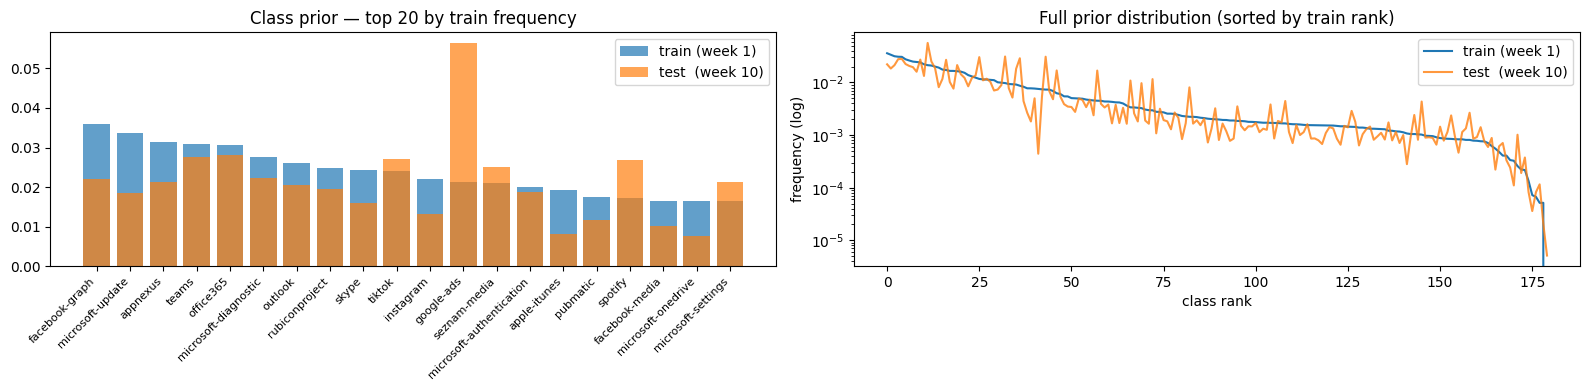

L1(test, train) = 0.0025


In [3]:
# load reference week for train_prior
ref_true, _, _, _ = load_week(REF_WN)
train_prior = np.bincount(ref_true, minlength=K).astype(float)
train_prior /= train_prior.sum()

true_counts = np.bincount(true, minlength=K).astype(float)
test_prior  = true_counts / true_counts.sum()

# top-20 classes by train frequency
top20 = np.argsort(train_prior)[::-1][:20]
names = [idx2name.get(i, str(i)) for i in top20]

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
x = np.arange(len(top20))

axes[0].bar(x, train_prior[top20], label=f'train (week {REF_WN})', alpha=0.7)
axes[0].bar(x, test_prior[top20],  label=f'test  (week {WN})',     alpha=0.7)
axes[0].set_xticks(x); axes[0].set_xticklabels(names, rotation=45, ha='right', fontsize=8)
axes[0].set_title('Class prior — top 20 by train frequency'); axes[0].legend()

# full distribution sorted
sorted_idx = np.argsort(train_prior)[::-1]
axes[1].semilogy(train_prior[sorted_idx], label=f'train (week {REF_WN})', lw=1.5)
axes[1].semilogy(test_prior[sorted_idx],  label=f'test  (week {WN})',     lw=1.5, alpha=0.8)
axes[1].set_xlabel('class rank'); axes[1].set_ylabel('frequency (log)')
axes[1].set_title('Full prior distribution (sorted by train rank)'); axes[1].legend()

plt.tight_layout()
plt.show()
print(f"L1(test, train) = {np.mean(np.abs(test_prior - train_prior)):.4f}")

## Softmax confidence & entropy

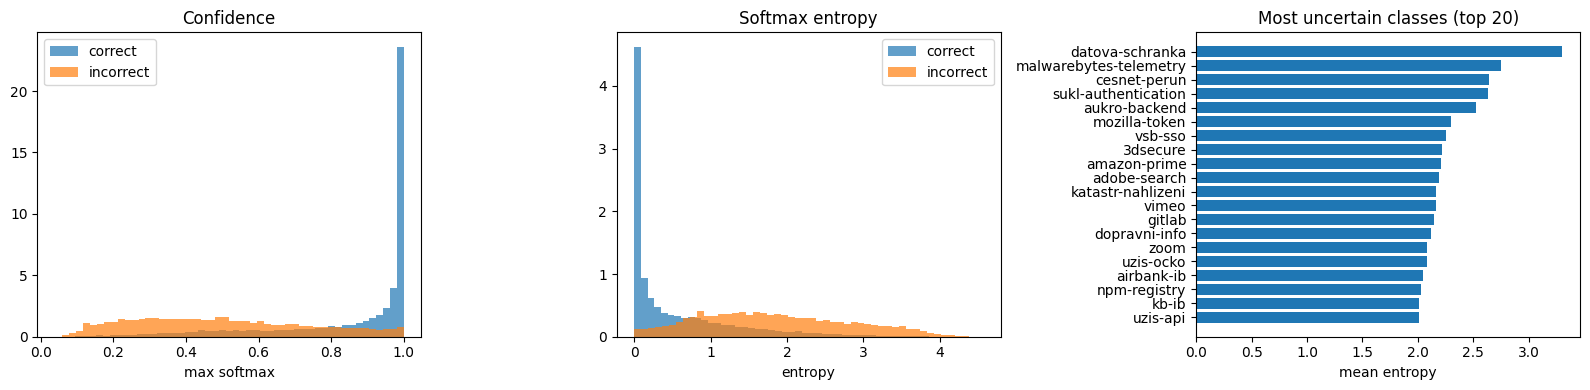

Overall accuracy: 0.6881   macro-F1: 0.5678


In [4]:
max_conf = softmax.max(axis=1)
entropy  = -np.sum(softmax * np.log(np.clip(softmax, 1e-12, 1)), axis=1)
correct  = (true == pred)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(max_conf[correct],  bins=50, alpha=0.7, label='correct',   density=True)
axes[0].hist(max_conf[~correct], bins=50, alpha=0.7, label='incorrect', density=True)
axes[0].set_xlabel('max softmax'); axes[0].set_title('Confidence'); axes[0].legend()

axes[1].hist(entropy[correct],  bins=50, alpha=0.7, label='correct',   density=True)
axes[1].hist(entropy[~correct], bins=50, alpha=0.7, label='incorrect', density=True)
axes[1].set_xlabel('entropy'); axes[1].set_title('Softmax entropy'); axes[1].legend()

# per-class mean entropy
cls_entropy = np.array([
    entropy[true == c].mean() if (true == c).sum() > 0 else np.nan
    for c in range(K)
])
top_ent = np.argsort(np.nan_to_num(cls_entropy, nan=-1))[::-1][:20]
axes[2].barh([idx2name.get(c, str(c)) for c in top_ent], cls_entropy[top_ent])
axes[2].set_xlabel('mean entropy'); axes[2].set_title('Most uncertain classes (top 20)')
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()
print(f"Overall accuracy: {correct.mean():.4f}   macro-F1: {f1_score(true, pred, average='macro', zero_division=0):.4f}")

## Per-class F1 vs train frequency

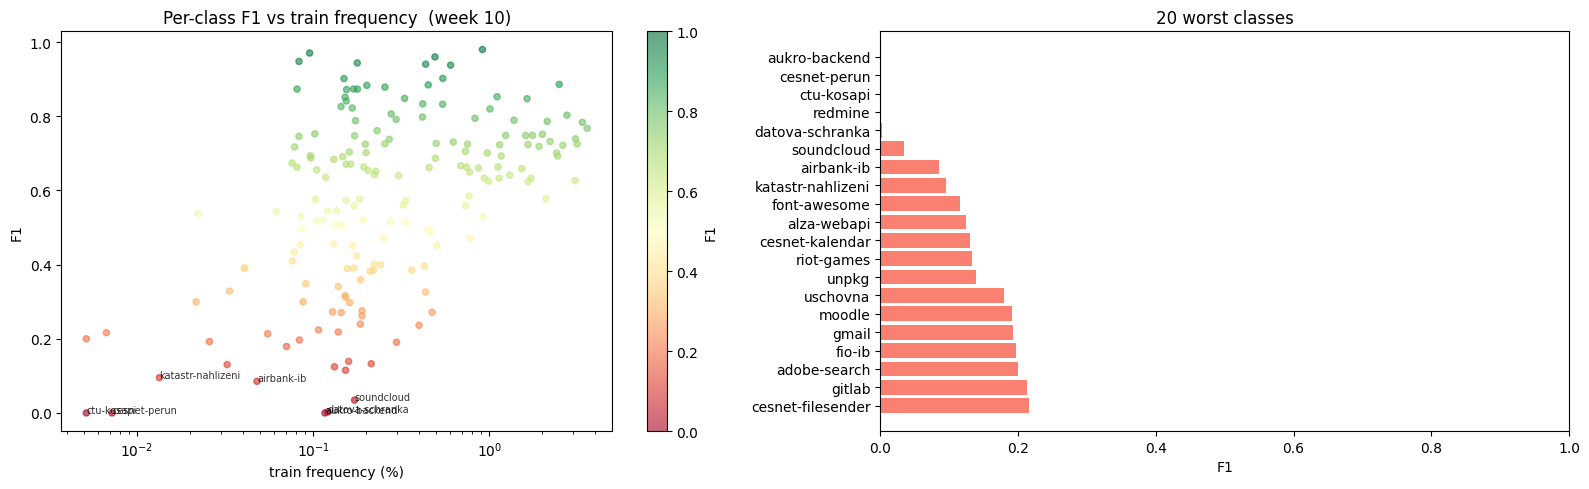

In [5]:
per_cls_f1 = f1_score(true, pred, average=None, zero_division=0, labels=list(range(K)))

# only classes present in test week
present = np.where(true_counts > 0)[0]
f1s  = per_cls_f1[present]
freq = train_prior[present]
names_p = [idx2name.get(c, str(c)) for c in present]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# scatter: train % vs F1
sc = axes[0].scatter(freq * 100, f1s, s=20, alpha=0.6, c=f1s, cmap='RdYlGn', vmin=0, vmax=1)
plt.colorbar(sc, ax=axes[0], label='F1')
# annotate worst classes
worst = present[np.argsort(f1s)[:8]]
for c in worst:
    axes[0].annotate(idx2name.get(c, str(c)), (train_prior[c]*100, per_cls_f1[c]),
                     fontsize=7, alpha=0.8)
axes[0].set_xlabel('train frequency (%)'); axes[0].set_ylabel('F1')
axes[0].set_title(f'Per-class F1 vs train frequency  (week {WN})')
axes[0].set_xscale('log')

# bar: bottom-20 F1
bottom20 = present[np.argsort(f1s)[:20]]
axes[1].barh([idx2name.get(c, str(c)) for c in bottom20], per_cls_f1[bottom20], color='salmon')
axes[1].set_xlabel('F1'); axes[1].set_title('20 worst classes')
axes[1].invert_yaxis(); axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.show()

## Label shift estimation

In [6]:
from plot_paper_figures import build_bbse, estimate_label_dist, sld_em_estimation

ref_true_r, ref_pred_r, ref_sm_r, _ = load_week(REF_WN)
C_T_pinv, C_T, p_train_bbse, _ = build_bbse(ref_true_r, ref_pred_r, ref_sm_r, K)

bbse_est, q_hat = estimate_label_dist(pred, K, C_T_pinv)
naive_est        = q_hat.copy()
em_est           = sld_em_estimation(train_prior, softmax)

def l1(a, b): return float(np.mean(np.abs(np.asarray(a) - np.asarray(b))))

print(f"L1 errors (week {WN}):")
print(f"  static (train prior): {l1(train_prior, test_prior):.5f}")
print(f"  naive  (argmax freq): {l1(naive_est,   test_prior):.5f}")
print(f"  BBSE               : {l1(bbse_est,    test_prior):.5f}")
print(f"  SLD-EM             : {l1(em_est,      test_prior):.5f}")

# plot top-30 classes
top30 = np.argsort(train_prior)[::-1][:30]
x = np.arange(len(top30))
w = 0.2
fig, ax = plt.subplots(figsize=(16, 4))
ax.bar(x - 1.5*w, test_prior[top30]*100,  w, label='true',   color='black',  alpha=0.8)
ax.bar(x - 0.5*w, train_prior[top30]*100, w, label='train',  color='gray',   alpha=0.6)
ax.bar(x + 0.5*w, naive_est[top30]*100,   w, label='naive',  color='orange', alpha=0.7)
ax.bar(x + 1.5*w, bbse_est[top30]*100,    w, label='BBSE',   color='steelblue', alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels([idx2name.get(c, str(c)) for c in top30], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('frequency (%)'); ax.set_title(f'Label shift estimation — top 30 classes (week {WN})')
ax.legend(); plt.tight_layout(); plt.show()

L1 errors (week 10):
  static (train prior): 0.00252
  naive  (argmax freq): 0.00141
  BBSE               : 0.00141
  SLD-EM             : 0.00312


## Confusion matrix (top-N classes)

In [7]:
TOP_N = 20   # <── change this

top_n_cls = np.argsort(train_prior)[::-1][:TOP_N]
mask = np.isin(true, top_n_cls) & np.isin(pred, top_n_cls)

cm = confusion_matrix(true[mask], pred[mask], labels=top_n_cls)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(1)

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label='P(pred | true)')
ticks = [idx2name.get(c, str(c)) for c in top_n_cls]
ax.set_xticks(range(TOP_N)); ax.set_xticklabels(ticks, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(TOP_N)); ax.set_yticklabels(ticks, fontsize=8)
ax.set_xlabel('predicted'); ax.set_ylabel('true')
ax.set_title(f'Normalised confusion matrix — top {TOP_N} classes (week {WN})')
plt.tight_layout(); plt.show()

## Embeddings (UMAP / t-SNE) — top-N classes

In [8]:
from sklearn.manifold import TSNE

TOP_VIZ = 10    # <── classes to visualise
N_PER   = 200   # <── samples per class (keep it small for speed)

top_viz = np.argsort(train_prior)[::-1][:TOP_VIZ]
idx = np.concatenate([
    np.where(true == c)[0][:N_PER] for c in top_viz if (true == c).sum() > 0
])

print(f"Running t-SNE on {len(idx)} points ({TOP_VIZ} classes × ≤{N_PER})...")
Z = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=500).fit_transform(embeddings[idx])

colors = cm.tab20(np.linspace(0, 1, TOP_VIZ))
fig, ax = plt.subplots(figsize=(10, 8))
for ci, c in enumerate(top_viz):
    m = true[idx] == c
    if m.sum() == 0: continue
    ax.scatter(Z[m, 0], Z[m, 1], s=8, alpha=0.6, color=colors[ci],
               label=idx2name.get(c, str(c)))
ax.legend(markerscale=2, fontsize=8, loc='upper right')
ax.set_title(f't-SNE of embeddings — top {TOP_VIZ} classes (week {WN})')
ax.axis('off'); plt.tight_layout(); plt.show()

Running t-SNE on 2000 points (10 classes × ≤200)...


AttributeError: 'numpy.ndarray' object has no attribute 'tab20'

## Cross-week comparison — pick a class and track it

In [ ]:
CLASS_IDX = 0   # <── class index to track

wns, cls_f1s, cls_true_pct, cls_pred_pct = [], [], [], []
for f in week_files:
    wn = int(re.search(r'(\d+)$', f.stem).group(1))
    d  = np.load(f)
    t, p = d['true_labels'], d['pred_labels']
    wns.append(wn)
    cls_f1s.append(f1_score(t, p, average=None, zero_division=0, labels=list(range(K)))[CLASS_IDX])
    cls_true_pct.append((t == CLASS_IDX).mean() * 100)
    cls_pred_pct.append((p == CLASS_IDX).mean() * 100)

cls_name = idx2name.get(CLASS_IDX, str(CLASS_IDX))
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(wns, cls_f1s, marker='o', ms=4)
axes[0].axvline(REF_WN, color='gray', linestyle='--', label=f'train week {REF_WN}')
axes[0].set_xlabel('week'); axes[0].set_ylabel('F1')
axes[0].set_title(f'Per-week F1 — {cls_name}'); axes[0].legend()

axes[1].plot(wns, cls_true_pct, marker='o', ms=4, label='true %')
axes[1].plot(wns, cls_pred_pct, marker='s', ms=4, label='predicted %')
axes[1].axvline(REF_WN, color='gray', linestyle='--', label=f'train week {REF_WN}')
axes[1].set_xlabel('week'); axes[1].set_ylabel('frequency (%)')
axes[1].set_title(f'Per-week frequency — {cls_name}'); axes[1].legend()

plt.tight_layout(); plt.show()